### Phase 1: Data Exploration

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('titanic.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


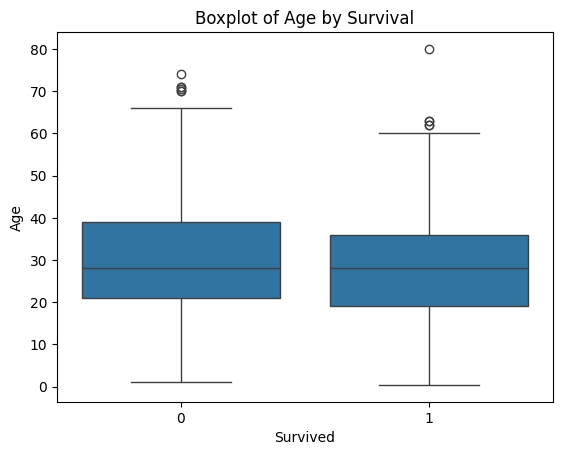

In [5]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Boxplot of Age by Survival')
plt.show()

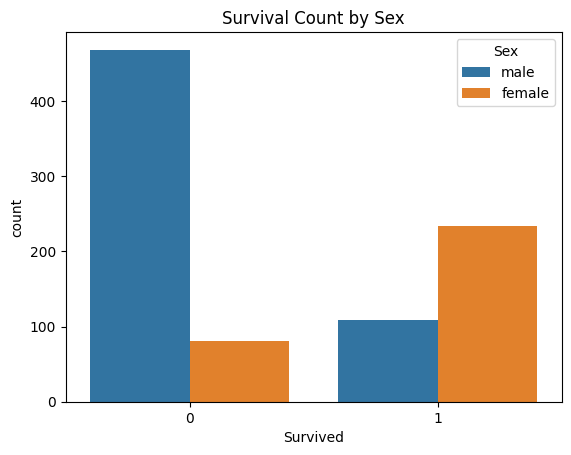

In [6]:

sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Sex')
plt.show()


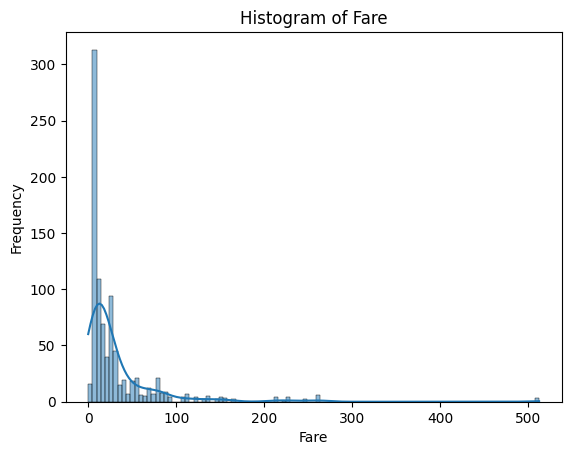

In [7]:
sns.histplot(df['Fare'], kde=True)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Histogram of Fare')
plt.show()

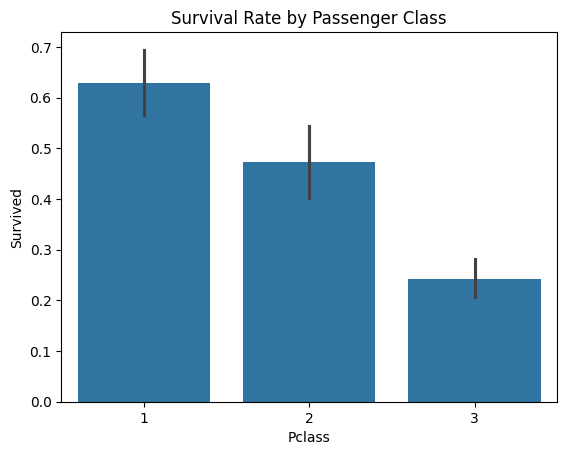

In [8]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

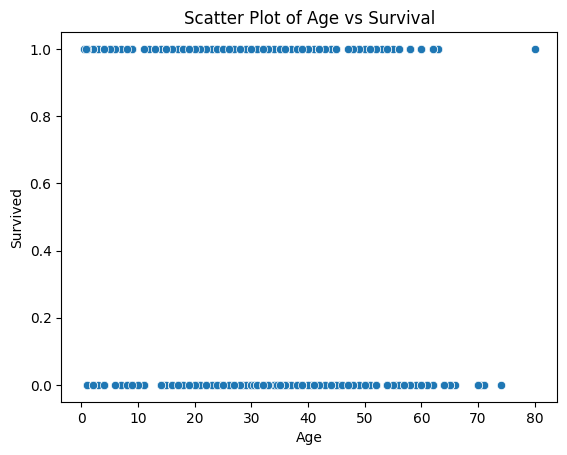

In [9]:
sns.scatterplot(x='Age', y='Survived', data=df)
plt.title('Scatter Plot of Age vs Survival')
plt.show()

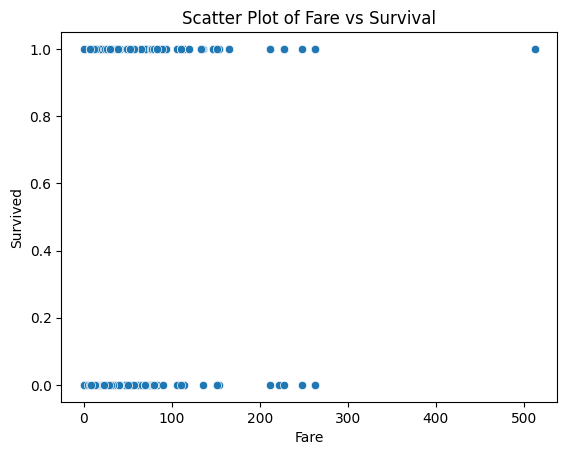

In [10]:
sns.scatterplot(x='Fare', y='Survived', data=df)
plt.title('Scatter Plot of Fare vs Survival')
plt.show()

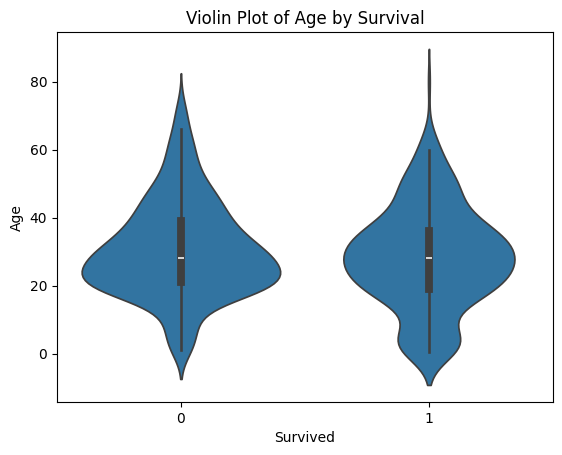

In [11]:
sns.violinplot(x='Survived', y='Age', data=df)
plt.title('Violin Plot of Age by Survival')
plt.show()

### Phase 2: Data Preprocessing

In [12]:
mv=df.isnull().sum()
print(mv)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['PassengerId'], axis=1, inplace=True)
df.drop(['Name'], axis=1, inplace=True)
df.drop(['Ticket'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [14]:
mv=df.isnull().sum()
print(mv)

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [15]:
from sklearn.preprocessing import LabelEncoder

label=LabelEncoder()

df['Sex']=label.fit_transform(df['Sex'])
df['Embarked']=label.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [16]:
df.tail()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
886,0,2,1,27.0,0,0,13.00,2
887,1,1,0,19.0,0,0,30.00,2
888,0,3,0,28.0,1,2,23.45,2
889,1,1,1,26.0,0,0,30.00,0
890,0,3,1,32.0,0,0,7.75,1


In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
numerical_features = [ 'Age', 'SibSp', 'Parch', 'Fare']
scaler_minmax = MinMaxScaler()

df[numerical_features]=scaler_minmax.fit_transform(df[numerical_features])

df.iloc[:20]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,0.271174,0.125,0.000000,0.014151,2
1,1,1,0,0.472229,0.125,0.000000,0.139136,0
2,1,3,0,0.321438,0.000,0.000000,0.015469,2
3,1,1,0,0.434531,0.125,0.000000,0.103644,2
4,0,3,1,0.434531,0.000,0.000000,0.015713,2
5,0,3,1,0.346569,0.000,0.000000,0.016510,1
6,0,1,1,0.673285,0.000,0.000000,0.101229,2
7,0,3,1,0.019854,0.375,0.166667,0.041136,2
8,1,3,0,0.334004,0.000,0.333333,0.021731,2
9,1,2,0,0.170646,0.125,0.000000,0.058694,0


In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Survived'])
y=df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)


### Phase 3: Model Development

In [19]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#part6
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
y_pred_linear_svm = linear_svm.predict(X_test)
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear_svm))


#part7
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
y_pred_rbf_svm = rbf_svm.predict(X_test)
print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf_svm))

#part8
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))



Linear SVM Accuracy: 0.776536312849162
RBF SVM Accuracy: 0.8044692737430168
Logistic Regression Accuracy: 0.7932960893854749


### Phase 4: Model Evaluation

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import seaborn as sns
sns.set(style="whitegrid")
# Train the models again with Probability Estimates
linear_svm = SVC(kernel='linear', probability=True)
linear_svm.fit(X_train, y_train)
y_prob_linear_svm = linear_svm.predict_proba(X_test)

rbf_svm = SVC(kernel='rbf', probability=True)
rbf_svm.fit(X_train, y_train)
y_prob_rbf_svm = rbf_svm.predict_proba(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_prob_log_reg = log_reg.predict_proba(X_test)



In [23]:
y_test_binarized = label_binarize(y_test, classes=[0, 1])

In [24]:
# ROC Curve
fpr_linear_svm, tpr_linear_svm, _ = roc_curve(y_test_binarized, y_prob_linear_svm[:,1])
fpr_rbf_svm, tpr_rbf_svm, _ = roc_curve(y_test_binarized, y_prob_rbf_svm[:,1])
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test_binarized, y_prob_log_reg[:,1])

#Calculate AUC for Models
roc_auc_linear_svm = auc(fpr_linear_svm, tpr_linear_svm)
roc_auc_rbf_svm = auc(fpr_rbf_svm, tpr_rbf_svm)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

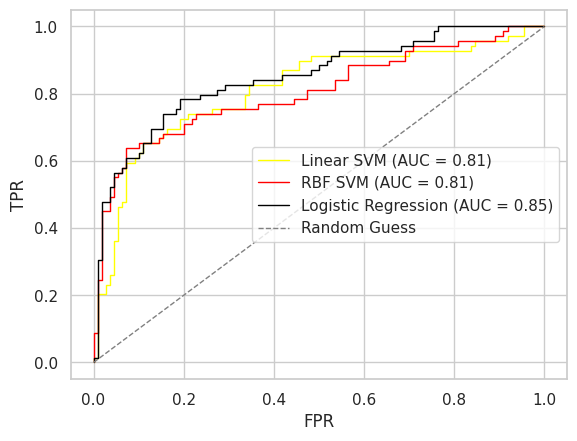

In [34]:

# Plot ROC curves
plt.figure()
plt.plot(fpr_linear_svm, tpr_linear_svm, color='yellow', lw=1, label='Linear SVM (AUC = %0.2f)' % roc_auc_linear_svm)
plt.plot(fpr_rbf_svm, tpr_rbf_svm, color='red', lw=1, label='RBF SVM (AUC = %0.2f)' % roc_auc_rbf_svm)
plt.plot(fpr_log_reg, tpr_log_reg, color='black', lw=1, label='Logistic Regression (AUC = %0.2f)' % roc_auc_log_reg)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Guess')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='right')
plt.show()




In [38]:
# Best decision threshold for Logistic Regression
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_binarized, y_prob_log_reg[:,1])
f1_scores = (2 * precision * recall) / (precision + recall)
best_threshold_index = f1_scores.argmax()
best_threshold = thresholds[best_threshold_index]

print("Best threshold:", best_threshold)

Best threshold: 0.40580617762260984
